In [2]:
import gsw
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [3]:
Nanaimo_X, Nanaimo_Y = 215, 498
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
Tp_init = 10
g = 9.81

In [4]:
ok = 25
print (mesh.gdept_1d[0, ok].values)
depth_outfall = 67
rho_fresh = gsw.rho(0, Tp_init, 0)
print (rho_fresh)
rho_ref = 1000

76.58558444650434
999.7475308554326


In [5]:
h = np.arange(0, 10, 0.1)
Tp = np.zeros_like(h)
Sp = np.zeros_like(h)
rhop = np.zeros_like(h)
erho = np.zeros_like(h)

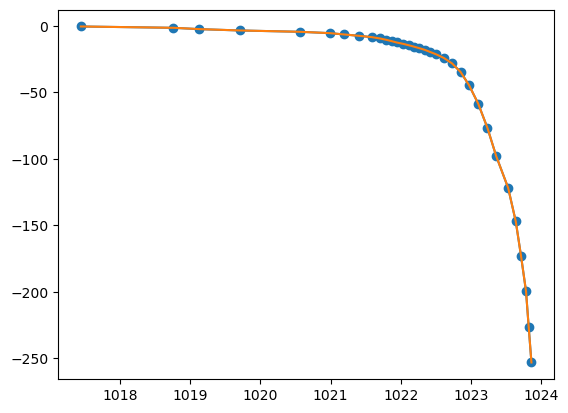

In [6]:
Nanaimo_GridT_Jul21 = xr.open_dataset('/ocean/cstang/results/WWTP/Nanaimo/01jul21_30d_wNutrients_D25/WWTP_1h_20210701_20210731_grid_T.nc')
region_temp = Nanaimo_GridT_Jul21.votemper[0, :, Nanaimo_Y-3:Nanaimo_Y+3, 
    Nanaimo_X-3: Nanaimo_X+3]
Ta = region_temp.where(region_temp > 0, drop=True).mean(dim=['x','y'])
region_sal = Nanaimo_GridT_Jul21.vosaline[0, :, Nanaimo_Y-3:Nanaimo_Y+3,
    Nanaimo_X-3:Nanaimo_X+3]
Sa = region_sal.where(region_sal > 0, drop=True).mean(dim=['x','y'])
region_rho = Nanaimo_GridT_Jul21.sigma_theta[0, :, Nanaimo_Y-3:Nanaimo_Y+3,
    Nanaimo_X-3:Nanaimo_X+3]
rho_amb = region_rho.where(region_rho > 0, drop=True).mean(dim=['x','y']) + 1000

mk = Sa.shape[0]

plt.plot(rho_amb, -mesh.gdept_1d[0, 0:mk], '-o')    
rhoa = gsw.rho(Sa, Ta, 0)
plt.plot(rhoa, -mesh.gdept_1d[0, 0:mk]);

In [10]:
rhoa

<xarray.DataArray 'vosaline' (deptht: 33)> Size: 264B
array([1017.43847532, 1018.76291142, 1019.13916456, 1019.70946441,
       1020.56451955, 1020.98528825, 1021.19403396, 1021.40124195,
       1021.58538145, 1021.70306365, 1021.7931493 , 1021.86953922,
       1021.94024958, 1022.03275463, 1022.11123183, 1022.18645617,
       1022.26179776, 1022.34007785, 1022.41069567, 1022.50286305,
       1022.61324826, 1022.73095299, 1022.85330564, 1022.97267062,
       1023.10419176, 1023.23506053, 1023.36193124, 1023.53171745,
       1023.6403721 , 1023.71553182, 1023.78644765, 1023.82434212,
       1023.86342435])
Coordinates:
  * deptht         (deptht) float32 132B 0.5 1.5 2.5 3.5 ... 199.6 226.3 253.1
    time_centered  datetime64[ns] 8B 2021-07-01T00:30:00
    time_counter   datetime64[ns] 8B 2021-07-01T00:30:00
Attributes:
    standard_name:       sea_water_reference_salinity
    long_name:           Reference Salinity
    units:               g kg-1
    online_operation:    average
    interval_operation:  40 s
    interval_write:      1 h
    cell_methods:        time: mean (interval: 40 s)
    cell_measures:       area: area

In [12]:
profile = np.array([rhoa, -mesh.gdept_1d[0, 0:mk].values])
np.savetxt("profile.txt", profile

array([[ 1.01743848e+03,  1.01876291e+03,  1.01913916e+03,
         1.01970946e+03,  1.02056452e+03,  1.02098529e+03,
         1.02119403e+03,  1.02140124e+03,  1.02158538e+03,
         1.02170306e+03,  1.02179315e+03,  1.02186954e+03,
         1.02194025e+03,  1.02203275e+03,  1.02211123e+03,
         1.02218646e+03,  1.02226180e+03,  1.02234008e+03,
         1.02241070e+03,  1.02250286e+03,  1.02261325e+03,
         1.02273095e+03,  1.02285331e+03,  1.02297267e+03,
         1.02310419e+03,  1.02323506e+03,  1.02336193e+03,
         1.02353172e+03,  1.02364037e+03,  1.02371553e+03,
         1.02378645e+03,  1.02382434e+03,  1.02386342e+03],
       [-5.00000273e-01, -1.50000314e+00, -2.50001150e+00,
        -3.50003055e+00, -4.50007042e+00, -5.50015083e+00,
        -6.50031022e+00, -7.50062342e+00, -8.50123623e+00,
        -9.50243254e+00, -1.05047653e+01, -1.15093113e+01,
        -1.25181668e+01, -1.35354121e+01, -1.45689822e+01,
        -1.56342874e+01, -1.67611734e+01, -1.80071346e+

### Calculating g' ###

In [41]:
gp_init = g * (rhoa[ok].values - rho_fresh) / rho_ref

In [40]:
drho_amb = np.zeros(25)
z_levels_idx = np.arange(25,0,-1)

for ii,z_idx in enumerate(z_levels_idx):
    drho_amb[z_idx-1] = rho_amb[z_idx] - rho_amb[z_idx-1]
    
N2 = -9.81/rho_ref * drho_amb

In [61]:
BV2 = (-g/rho_ref * (rhoa[0:ok].values - rhoa[1:ok+1].values) 
       / mesh.e3t_0[0, 0:ok, Nanaimo_Y, Nanaimo_X])


In [62]:
BV2.shape
N2.shape

(25,)

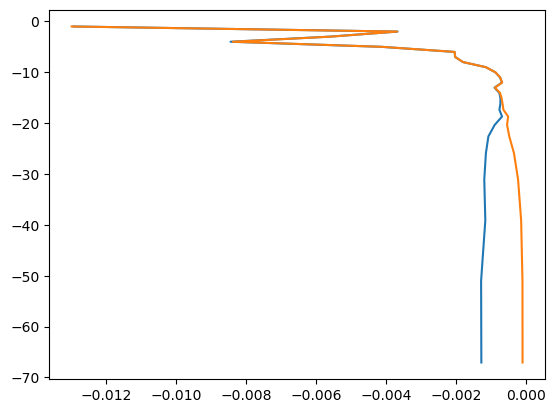

In [63]:
plt.plot(N2, -mesh.gdepw_1d[0, 1:ok+1])
plt.plot(-BV2, -mesh.gdepw_1d[0, 1:ok+1]);

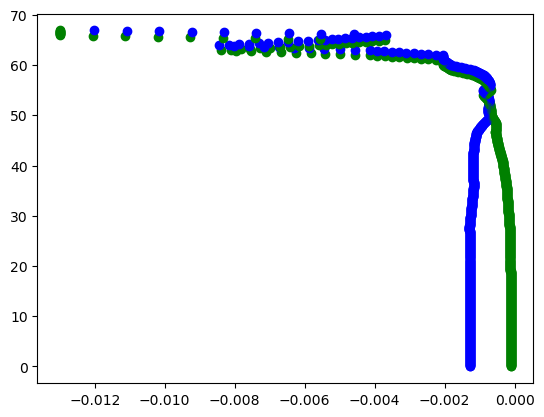

In [67]:
zz = np.arange(0, depth_outfall, 0.1)
for z in zz:
    depth = depth_outfall - z
    plt.plot(np.interp(depth, mesh.gdepw_1d[0,:25], N2), z, 'bo')
    plt.plot(np.interp(depth, mesh.gdepw_1d[0,1:ok+1], -BV2), z, 'go')

### Summary: ###
Significant differences in g' 

### Look at rho variations using T and S ###

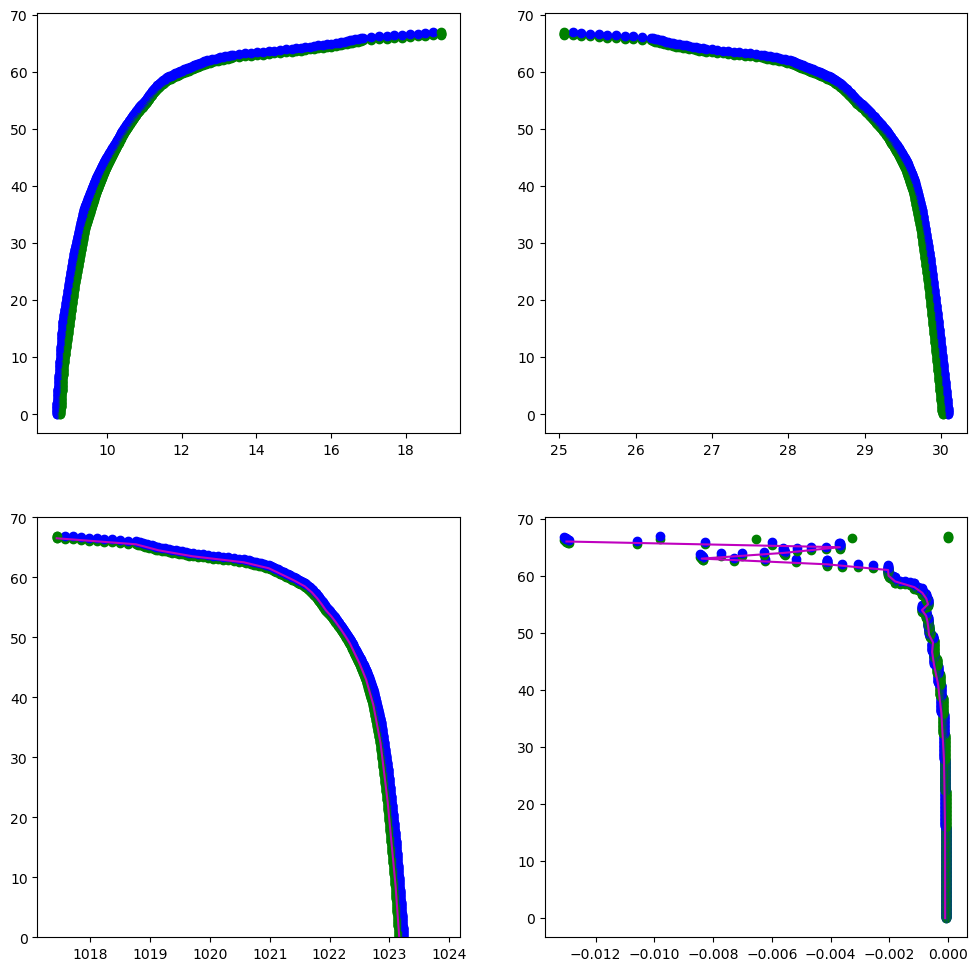

In [84]:
dd = 0.2
zz = np.arange(0, depth_outfall, 0.1)
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
for z in zz:
    depth = depth_outfall - z
    tac = np.interp(depth, mesh.gdepw_1d[0, :33], Ta)
    sac = np.interp(depth, mesh.gdepw_1d[0, :33], Sa)
    rho_ac = gsw.rho(sac, tac, 0)
    tas = np.interp(depth, mesh.gdept_1d[0, :mk], Ta)
    sas = np.interp(depth, mesh.gdept_1d[0, :mk], Sa)
    rho_as = gsw.rho(sas, tas, 0)
    axs[0, 0].plot(tac, z, 'bo')
    axs[0, 1].plot(sac, z, 'bo')
    axs[1, 0].plot(rho_ac, z, 'bo')
    axs[0, 0].plot(tas, z, 'go')
    axs[0, 1].plot(sas, z, 'go')
    axs[1, 0].plot(rho_as, z, 'go')

    tac_p = np.interp(depth+dd, mesh.gdepw_1d[0, :33], Ta)
    sac_p = np.interp(depth+dd, mesh.gdepw_1d[0, :33], Sa)
    rac_p = gsw.rho(sac_p, tac_p, 0)
    tac_m = np.interp(depth-dd, mesh.gdepw_1d[0, :33], Ta)
    sac_m = np.interp(depth-dd, mesh.gdepw_1d[0, :33], Sa)
    rac_m = gsw.rho(sac_m, tac_m, 0)
    n2c = -g * (rac_p - rac_m)/(2*dd) / rho_ref
    axs[1, 1].plot(n2c, z, 'bo')

    tas_p = np.interp(depth+dd, mesh.gdept_1d[0, :mk], Ta)
    sas_p = np.interp(depth+dd, mesh.gdept_1d[0, :mk], Sa)
    ras_p = gsw.rho(sas_p, tas_p, 0)
    tas_m = np.interp(depth-dd, mesh.gdept_1d[0, :mk], Ta)
    sas_m = np.interp(depth-dd, mesh.gdept_1d[0, :mk], Sa)
    ras_m = gsw.rho(sas_m, tas_m, 0)
    bvs = -g * (ras_p - ras_m)/(2*dd) / rho_ref
    axs[1, 1].plot(bvs, z, 'go')
    
axs[1, 0].plot(rhoa, depth_outfall-mesh.gdept_1d[0, 0:mk], 'm');
axs[1, 0].set_ylim(0, 70);
axs[1, 1].plot(-BV2, depth_outfall-mesh.gdepw_1d[0, 1:ok+1], 'm');

In [4]:
Tp[0] = 20
Sp[0] = 5
rhop[0] = gsw.rho(Sp[0], Tp[0], 0)
erho[0] = rhop[0]

In [5]:
alpha = 0.1
bb = 1 + alpha*h

In [9]:
for ii, d in enumerate(h[1:]):
    Tp[ii+1] = (Tp[ii] + alpha*Ta) / (1 + alpha)
    Sp[ii+1] = (Sp[ii] + alpha*Sa) / (1 + alpha)
    rhop[ii+1] = gsw.rho(Sp[ii+1], Tp[ii+1], 0)
    erho[ii+1] = (erho[ii] + alpha*rhoa) / (1 + alpha)

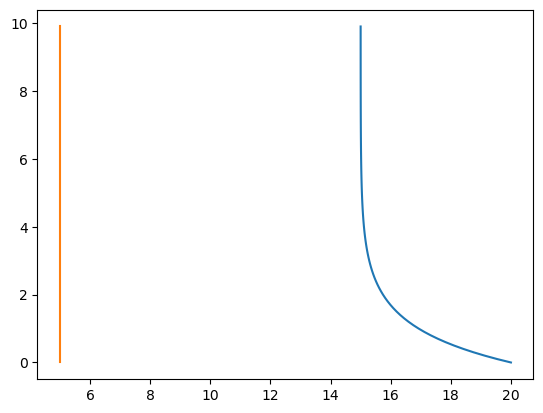

In [10]:
fig, ax = plt.subplots(1, 1)
ax.plot(Tp, h)
ax.plot(Sp, h);

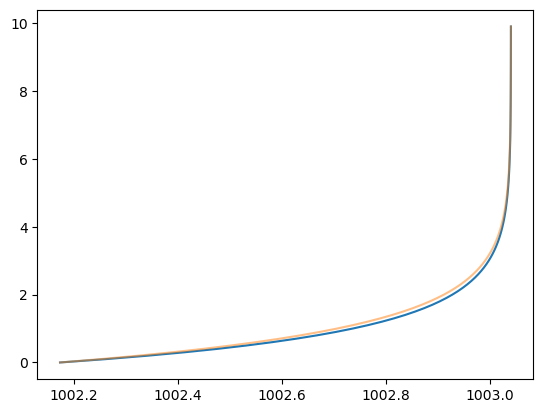

In [12]:
fig, ax = plt.subplots(1, 1)
ax.plot(rhop, h)
ax.plot(erho, h, alpha=0.5);